### Exploratory Data Analysis: Customer Churn
##### Visualizing distributions, feature relationships, and class imbalances.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for professional aesthetics
sns.set_theme(style="whitegrid")

In [2]:
# Load Data
dataset = pd.read_csv('../data/churn-modelling.csv')
dataset = dataset.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

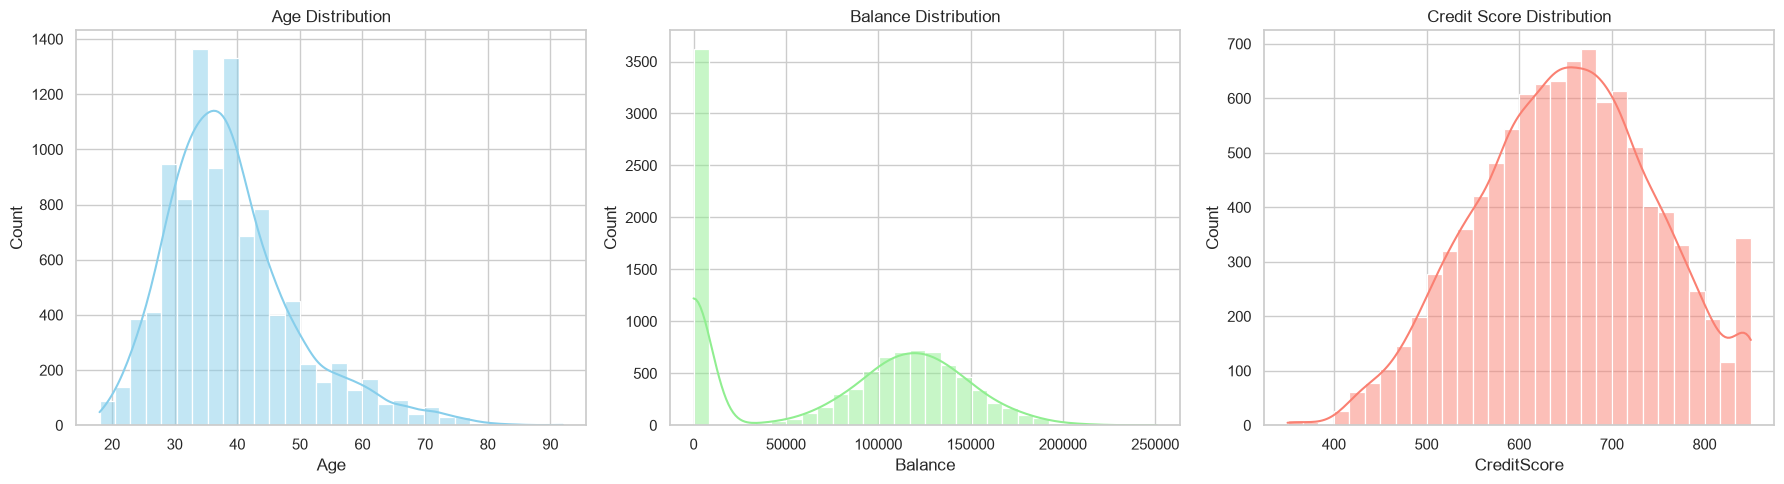

In [3]:
# Univariate Analysis (Distributions)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(dataset['Age'], bins=30, kde=True, ax=axes[0], color='skyblue').set_title('Age Distribution')
sns.histplot(dataset['Balance'], bins=30, kde=True, ax=axes[1], color='lightgreen').set_title('Balance Distribution')
sns.histplot(dataset['CreditScore'], bins=30, kde=True, ax=axes[2], color='salmon').set_title('Credit Score Distribution')
plt.tight_layout()
plt.show()

C:\Users\viren\AppData\Local\Temp\ipykernel_16184\877843515.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Age', data=dataset, palette='Set2', ax=axes[1, 1]).set_title('Age vs Churn')


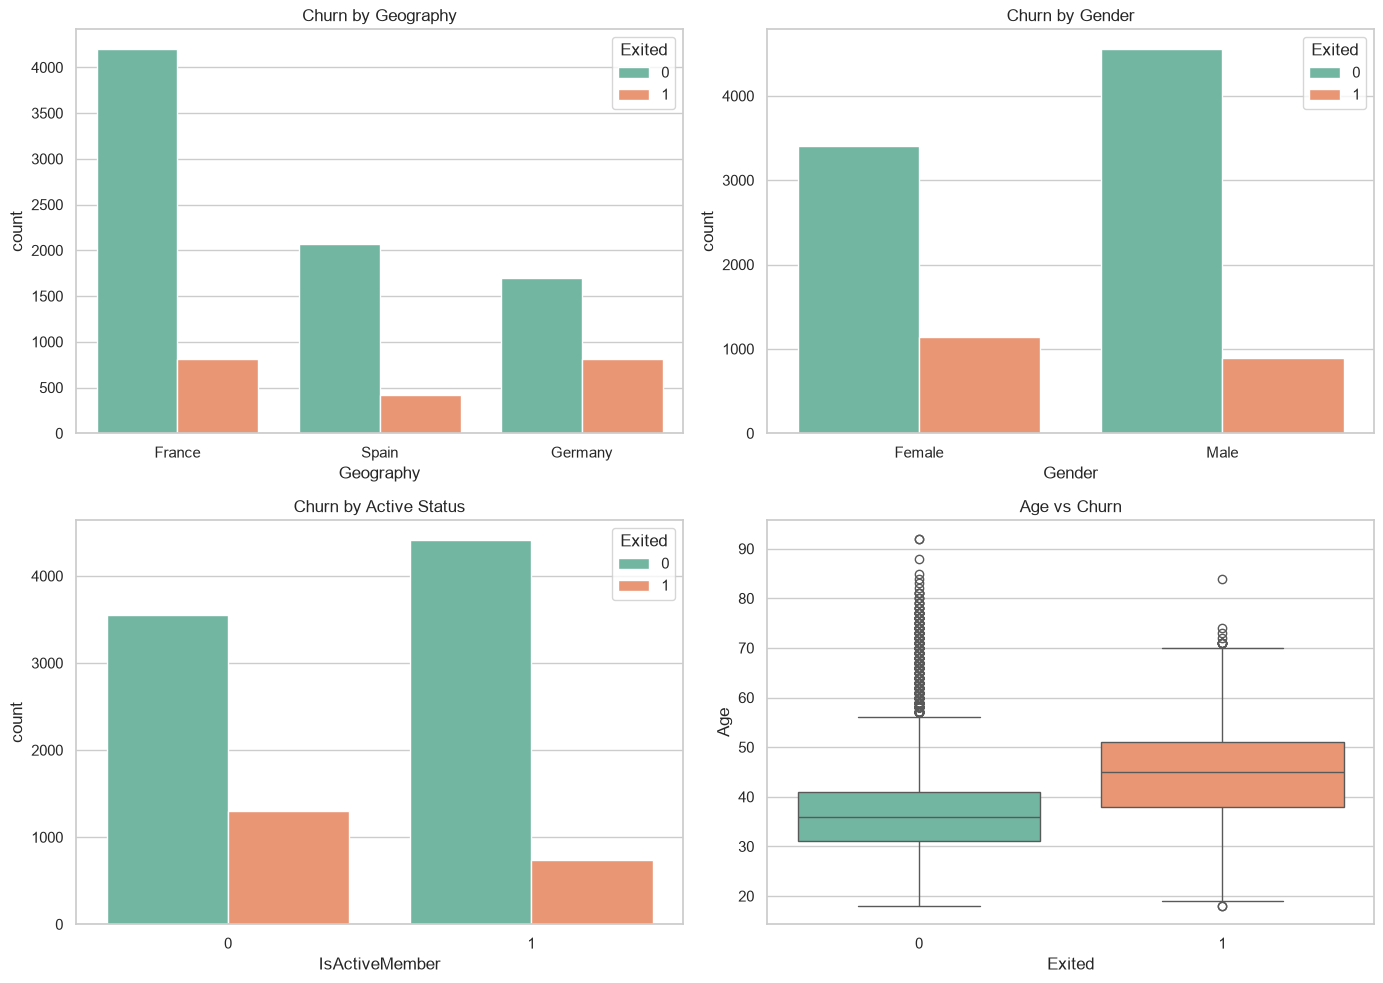

In [4]:
# Bivariate Analysis (Target vs Features)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(x='Geography', hue='Exited', data=dataset, palette='Set2', ax=axes[0, 0]).set_title('Churn by Geography')
sns.countplot(x='Gender', hue='Exited', data=dataset, palette='Set2', ax=axes[0, 1]).set_title('Churn by Gender')
sns.countplot(x='IsActiveMember', hue='Exited', data=dataset, palette='Set2', ax=axes[1, 0]).set_title('Churn by Active Status')
sns.boxplot(x='Exited', y='Age', data=dataset, palette='Set2', ax=axes[1, 1]).set_title('Age vs Churn')
plt.tight_layout()
plt.show()

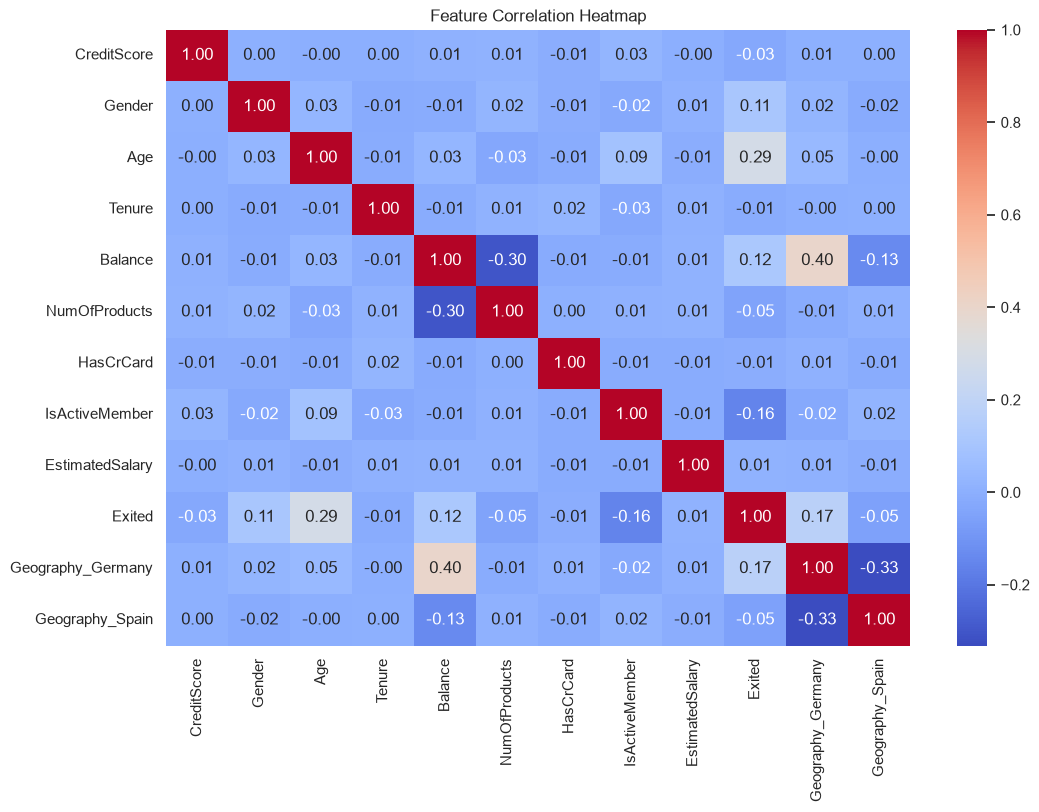

In [6]:
# Correlation Heatmap
corr_data = dataset.copy()
corr_data['Gender'] = corr_data['Gender'].map({'Male': 0, 'Female': 1})
corr_data = pd.get_dummies(corr_data, columns=['Geography'], drop_first=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_data.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title('Feature Correlation Heatmap')
plt.show()